In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


In [13]:
#%matplotlib notebook
# oppure se usi JupyterLab / VS Code:
%matplotlib widget

Salvataggio dell'animazione in corso su 'percolazione_2d.gif'...
Completato! La GIF è pronta e si fermerà al termine della simulazione.


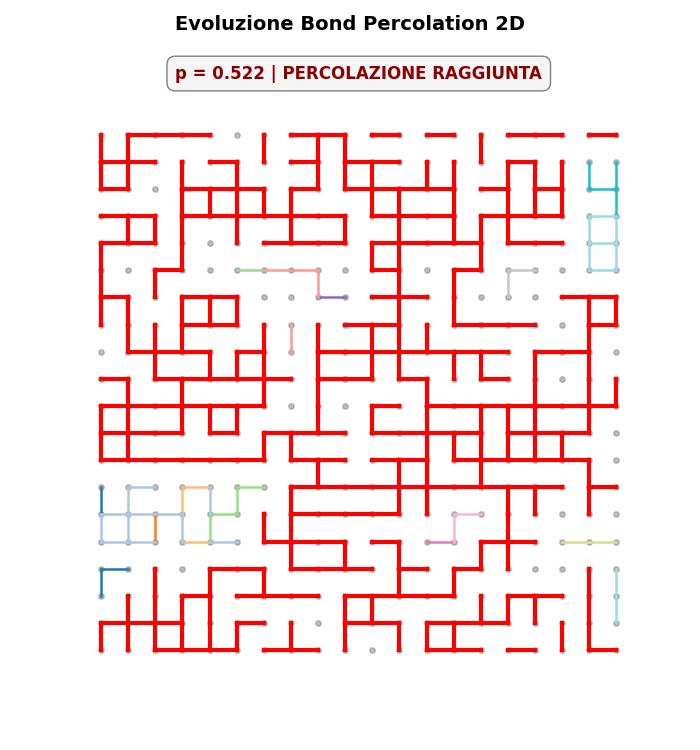

In [15]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.size = [1] * n

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i])
        return self.parent[i]

    def union(self, i, j):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i
            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]

def crea_animazione_powerpoint(L=20, fps=30, filename="percolazione_2d.gif"):
    N = L * L
    TOP, BOTTOM = N, N + 1
    dsu = UnionFind(N + 2)

    for col in range(L):
        dsu.union(TOP, col)
        dsu.union(BOTTOM, (L - 1) * L + col)

    legami = []
    for r in range(L):
        for c in range(L):
            node = r * L + c
            if c + 1 < L:
                legami.append((node, r * L + (c + 1), (r, c), (r, c + 1)))
            if r + 1 < L:
                legami.append((node, (r + 1) * L + c, (r, c), (r + 1, c)))

    np.random.shuffle(legami)
    num_totale_legami = len(legami)

    fig, ax = plt.subplots(figsize=(7, 7.5))
    
    cmap = plt.colormaps['tab20']
    
    grid_x, grid_y = np.meshgrid(range(L), range(L))
    ax.scatter(grid_x, grid_y, color='gray', s=15, alpha=0.5, zorder=1)

    lines_drawn = []
    
    # 1. TESTO SPOSTATO IN ALTO (Fuori dalla griglia di gioco)
    text_info = ax.text(0.5, 1.02, '', transform=ax.transAxes, fontsize=12,
                        ha='center', va='bottom', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray'))

    # Lasciamo un margine sopra i nodi estendendo il limite dell'asse Y
    ax.set_xlim(-0.5, L - 0.5)
    ax.set_ylim(L - 0.5, -1.5) # Modificato da -0.5 a -1.5 per creare spazio in alto
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.suptitle("Evoluzione Bond Percolation 2D", fontsize=14, fontweight='bold', y=0.98)

    # Variabile per fermare l'animazione qualche frame DOPO la percolazione per permettere di vederla
    frames_totali = []
    
    def update(frame):
        if frame >= num_totale_legami:
            return lines_drawn

        u, v, p1, p2 = legami[frame]
        dsu.union(u, v)

        p_attuale = (frame + 1) / num_totale_legami
        percola = (dsu.find(TOP) == dsu.find(BOTTOM))

        root_u = dsu.find(u)
        color = cmap((root_u % 20) / 20.0)
        
        line, = ax.plot([p1[1], p2[1]], [p1[0], p2[0]], color=color, linewidth=1.8, zorder=2)
        lines_drawn.append((line, u))

        if percola:
            cluster_percolante = dsu.find(TOP)
            for line_obj, node_u in lines_drawn:
                if dsu.find(node_u) == cluster_percolante:
                    line_obj.set_color('red')
                    line_obj.set_linewidth(3.0)
                    line_obj.set_zorder(4)

            text_info.set_text(f"p = {p_attuale:.3f} | PERCOLAZIONE RAGGIUNTA")
            text_info.set_color('darkred')
        else:
            text_info.set_text(f"p = {p_attuale:.3f} | Legami: {frame+1}/{num_totale_legami}")
            text_info.set_color('black')

        return lines_drawn

    # Troviamo esattamente a quale frame avviene la percolazione per non generare frame inutili dopo
    dsu_test = UnionFind(N + 2)
    for col in range(L):
        dsu_test.union(TOP, col)
        dsu_test.union(BOTTOM, (L - 1) * L + col)
        
    frame_percolazione = num_totale_legami
    for idx, (u, v, _, _) in enumerate(legami):
        dsu_test.union(u, v)
        if dsu_test.find(TOP) == dsu_test.find(BOTTOM):
            # Aggiungiamo 15 frame extra di pausa sul risultato finale prima di chiudere
            frame_percolazione = min(idx + 15, num_totale_legami)
            break

    anim = animation.FuncAnimation(fig, update, frames=frame_percolazione, 
                                  interval=1000//fps, blit=False, repeat=False)
    
    # 2. SALVATAGGIO IN FILE GIF PER POWERPOINT
    print(f"Salvataggio dell'animazione in corso su '{filename}'...")
    anim.save(filename, writer='pillow', fps=fps)
    
    # Applichiamo il blocco al loop direttamente sulla GIF salvata usando la libreria Pillow
    from PIL import Image
    img = Image.open(filename)
    img.save(filename, save_all=True, loop=1)
    
    print(f"Completato! La GIF è pronta e si fermerà al termine della simulazione.")
    
    plt.show()

# Esegui la funzione per creare e salvare il file
crea_animazione_powerpoint(L=20, fps=25, filename="percolazione_2d.gif")